# EO-LINCS project: Cube generation for Scientific Case Study (SCS) 1

### Explanatory power of novel EO data streams for predicting net carbon fluxes

**Objective**: The SCS1 trains an artificial neural network (ANN) to predict carbon fluxes, where meteorological and reflectance data from satellites are taken as input. The training will be based on the in-situ observations from eddy covariance flux tower provided by the FLUXNET2015 dataset.

**Outcomes**: A working data processing chain to incorporate Sentinel-2 data into the FLUXCOM-X framework 
that is updatable and expandable to all sites and other Sentinel data products. An analysis of the contributions 
of Sentinel-2 data for predicting NEE and analysis into the added value with regards to interannual variability, 
drought responses, and disturbance.

**Required datasets**:
* [Sentinel-2 L2A from CDSE](https://browser.stac.dataspace.copernicus.eu/?.language=en)
* [ERA-5 land](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview)
* [ESA CCI Biomass](https://climate.esa.int/en/projects/biomass/)


-------------------------------------------------------------

The following notebook shows how the users can load data from various sources defined in `scs1_config.yml` using the `MultiSourceDataStore` tool.

#### **What You Can Do with This Notebook** 
- Generate a configuration file based on fluxtower locations
- Load datasets from various sources as defined in the generated `scs1_config.yml`
- View the progress of each data request to the `MultiSourceDataStore`
- Quickly preview the datasets by plotting them.

#### **Requirements**  
Before you begin, follow these steps:

- Install `xcube-multistore` via conda-forge by running: `conda install --channel conda-forge xcube-multistore`
- To access [EO data via S3 from CDSE](https://documentation.dataspace.copernicus.eu/APIs/S3.html), [generate your S3 credentials](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets) and add them to the `data_stores` section in the `scs1_config.yml` file.  
- To access ERA5-Land data from the Copernicus Climate Data Store, obtain a **CDS Personal Access Token** by creating an account on the [CDS Website](https://cds.climate.copernicus.eu/). After logging in, navigate to your [user page](https://cds.climate.copernicus.eu/profile) to find your Personal Access Token. Add this token to the `data_stores` section in the `scs1_config.yml` file.  

Once you have it installed, you are ready to proceed.

This Multistore mainly works with a file called `scs1_config.yml` which is at the same file level as this notebook.
To understand what goes into the schema, you can read more [here](https://xcube-dev.github.io/xcube-multistore/).

-------------------------------------------------------

Let's import the `MultiSourceDataStore`

In [1]:
import yaml

import pandas as pd
from xcube_multistore import MultiSourceDataStore

You can find out how to fill out the config file by also using this super helpful function `get_config_schema()`. Run it and try expand the fields to learn more about the possible properties that the configuration file accepts along with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).

In [2]:
MultiSourceDataStore.get_config_schema()

This science case requires data from several flux sites. So we define them in a `scs1_sites.csv` file for easier management and access. For the purpose of this example, we will focus on the first 2 sites.

In [3]:
sites = pd.read_csv("scs1_sites.csv")
sites = sites.iloc[:2]
sites

,Site ID,latitude,longitude,IGBP
0,AU-Dry,-15.2588,132.3706,SAV
1,AU-How,-12.4943,131.1523,WSA


In the following cell, we will create the config object which will then be saved as `scs1_config.yml` for persistance and ready to be read by `MultiSourceDataStore`.

To read more about how this config file is structured, you can find the [Configuration Guide here](https://xcube-dev.github.io/xcube-multistore/config/), or refer to the notebook [setup_config.ipynb](../setup_config.ipynb).

Specifically, we are using the [single dataset object](https://xcube-dev.github.io/xcube-multistore/config/#single-dataset-object) and [data stores](https://xcube-dev.github.io/xcube-multistore/config/#store-object) schemas here.

In [4]:
time_range = ["2020-01-01", "2020-03-30"]

In [5]:
config = dict(datasets=[])
for index, site in sites.iterrows():
    # append config for Sentinel-2
    config_ds = dict(
        identifier=f"{site['Site ID']}_sen2",
        store="stac-pc",
        data_id="sentinel-2-l2a",
        open_params=dict(
            time_range=time_range,
            point=[site["longitude"], site["latitude"]],
            bbox_width=4000,
            spatial_res=10,
            asset_names=[
                "B01",
                "B02",
                "B03",
                "B04",
                "B05",
                "B06",
                "B07",
                "B08",
                "B8A",
                "B09",
                "B11",
                "B12",
                "SCL",
            ],
        ),
    )
    config["datasets"].append(config_ds)

    # append config for ERA5
    config_ds = dict(
        identifier=f"{site['Site ID']}_era5",
        store="cds",
        data_id="reanalysis-era5-single-levels-timeseries",
        open_params=dict(
            variable_names=["2m_temperature", "2m_dewpoint_temperature"],
            time_range=time_range,
            location=[site["longitude"], site["latitude"]],
        ),
    )
    config["datasets"].append(config_ds)

    # append config for ESA CCI
    config_ds = dict(
        identifier=f"{site['Site ID']}_ccibiomass",
        store="esa_cci",
        grid_mapping=f"{site['Site ID']}_sen2",
        data_id="esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.5-0.100m",
        open_params=dict(
            time_range=time_range,
        ),
    )
    config["datasets"].append(config_ds)

# define stores
config["data_stores"] = []
# add storage data store
config_store = dict(
    identifier="storage",
    store_id="file",
    store_params=dict(root="data"),
)
config["data_stores"].append(config_store)
# add ESA CCI data store
config_store = dict(
    identifier="esa_cci",
    store_id="cciodp",
)
config["data_stores"].append(config_store)
# add STAC data store
config_store = dict(
    identifier="stac-pc",
    store_id="stac-pc-ardc",
)
config["data_stores"].append(config_store)
# add CDS data store
config_store = dict(
    identifier="cds",
    store_id="cds",
    store_params=dict(
        endpoint_url="https://cds.climate.copernicus.eu/api",
        cds_api_key="<CDS_API_key>",
        normalize_names=True,
    ),
)
config["data_stores"].append(config_store)

In [6]:
with open("scs1_config.yml", "w") as file:
    yaml.dump(config, file, sort_keys=False)

Now, we can initialize the `MultiSourceDataStore` by passing the path to the `scs1_config.yml` which currently is on the same level as this notebook.

In [7]:
msds = MultiSourceDataStore("scs1_config.yml")

And we can display the overview of the configuration file for each dataset.

In [8]:
msds.display_config()

User-defined ID,Data Store ID,Data Store Params,Data ID,Open Data Params,Grid-Mapping,Format
AU-Dry_sen2,stac-pc-ardc,-,sentinel-2-l2a,"time_range: ['2020-01-01', '2020-03-30']; point: [132.3706, -15.2588]; bbox_width: 4000; spatial_res: 10; asset_names: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'SCL']",-,Zarr
AU-Dry_era5,cds,endpoint_url: https://cds.climate.copernicus.eu/api; cds_api_key: 8ba066d4-5195-4c1d-af91-6fb13bfc22df; normalize_names: True,reanalysis-era5-single-levels-timeseries,"variable_names: ['2m_temperature', '2m_dewpoint_temperature']; time_range: ['2020-01-01', '2020-03-30']; location: [132.3706, -15.2588]",-,Zarr
AU-Dry_ccibiomass,cciodp,-,esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.5-0.100m,"time_range: ['2020-01-01', '2020-03-30']",Like 'AU-Dry_sen2',Zarr
AU-How_sen2,stac-pc-ardc,-,sentinel-2-l2a,"time_range: ['2020-01-01', '2020-03-30']; point: [131.1523, -12.4943]; bbox_width: 4000; spatial_res: 10; asset_names: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'SCL']",-,Zarr
AU-How_era5,cds,endpoint_url: https://cds.climate.copernicus.eu/api; cds_api_key: 8ba066d4-5195-4c1d-af91-6fb13bfc22df; normalize_names: True,reanalysis-era5-single-levels-timeseries,"variable_names: ['2m_temperature', '2m_dewpoint_temperature']; time_range: ['2020-01-01', '2020-03-30']; location: [131.1523, -12.4943]",-,Zarr
AU-How_ccibiomass,cciodp,-,esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.5-0.100m,"time_range: ['2020-01-01', '2020-03-30']",Like 'AU-How_sen2',Zarr


We can display the selected bounding box as shown in the following cell.

In [9]:
msds.display_geolocations()

We can now generate the datacubes:

In [10]:
msds.generate()

Dataset identifier,Status,Message,Exception
AU-Dry_sen2,COMPLETED,Dataset 'AU-Dry_sen2' already generated.,-
AU-Dry_era5,COMPLETED,Dataset 'AU-Dry_era5' finished: 0:00:15,-
AU-Dry_ccibiomass,COMPLETED,Dataset 'AU-Dry_ccibiomass' finished: 0:00:49,-
AU-How_sen2,COMPLETED,Dataset 'AU-How_sen2' already generated.,-
AU-How_era5,COMPLETED,Dataset 'AU-How_era5' finished: 0:00:14,-
AU-How_ccibiomass,COMPLETED,Dataset 'AU-How_ccibiomass' finished: 0:00:47,-


xcube-cds version 1.2.0
2026-02-11 15:07:51,798 WARNING [2025-03-17T00:00:00] Please be aware that the generation of this dataset is using an alternative source for the ERA5 data and may be subject to changes over time (e.g. file format, data file structure, deprecation etc). This dataset should therefore be regarded as “experimental” and is **not recommended for use in a production environment**. 

Notification of changes via this catalogue entry banner and/or in the [Forum](https://forum.ecmwf.int/) will be provided on best efforts.
2026-02-11 15:07:51,798 INFO Request ID is 7415920a-762c-4bb1-afce-1dda2936eacf
2026-02-11 15:07:51,861 INFO status has been updated to accepted
2026-02-11 15:08:00,597 INFO status has been updated to running
2026-02-11 15:08:05,723 INFO status has been updated to successful


4072e70120281f59aefbab27096c24e.zip:   0%|          | 0.00/54.2k [00:00<?, ?B/s]

xcube-cds version 1.2.0
2026-02-11 15:08:55,872 WARNING [2025-03-17T00:00:00] Please be aware that the generation of this dataset is using an alternative source for the ERA5 data and may be subject to changes over time (e.g. file format, data file structure, deprecation etc). This dataset should therefore be regarded as “experimental” and is **not recommended for use in a production environment**. 

Notification of changes via this catalogue entry banner and/or in the [Forum](https://forum.ecmwf.int/) will be provided on best efforts.
2026-02-11 15:08:55,875 INFO Request ID is c9c9df8c-9ec1-43db-949a-ce0a60984108
2026-02-11 15:08:55,935 INFO status has been updated to accepted
2026-02-11 15:09:09,478 INFO status has been updated to successful


b99c19a3941d553fc6265fb8f87e131e.zip:   0%|          | 0.00/54.2k [00:00<?, ?B/s]

We can now open the data using the xcube datastore framework API as usual. Note that the multi-source data store requires a data store called `storage`, which is configured in our `scs1_config.yml` under the `data_stores` section.

In [11]:
ds = msds.stores.storage.open_data("AU-Dry_sen2.zarr")
ds

<xarray.Dataset> Size: 161MB
Dimensions:      (time: 18, y: 400, x: 400)
Coordinates:
  * time         (time) datetime64[ns] 144B 2020-01-02T01:27:09.024000 ... 20...
  * y            (y) float64 3kB 8.312e+06 8.312e+06 ... 8.308e+06 8.308e+06
  * x            (x) float64 3kB 8.601e+05 8.601e+05 ... 8.641e+05 8.641e+05
    spatial_ref  int64 8B ...
Data variables: (12/13)
    B01          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B02          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B03          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B04          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B05          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B06          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    ...           ...
    B08          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B09          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B11          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B12          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B8A          (time, y, x) float32 12MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    SCL          (time, y, x) float64 23MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://planetarycomputer.microsoft.com/api/stac/v1
    stac_item_id:        S2B_MSIL2A_20200102T012709_R131_T52LHJ_20201002T215923
    stac_item_ids:       {'2020-01-02T01:27:09.024000': ['S2B_MSIL2A_20200102...
    xcube_stac_version:  1.1.2

We can now select a variable for one timestep and plot it for a quick preview of the data

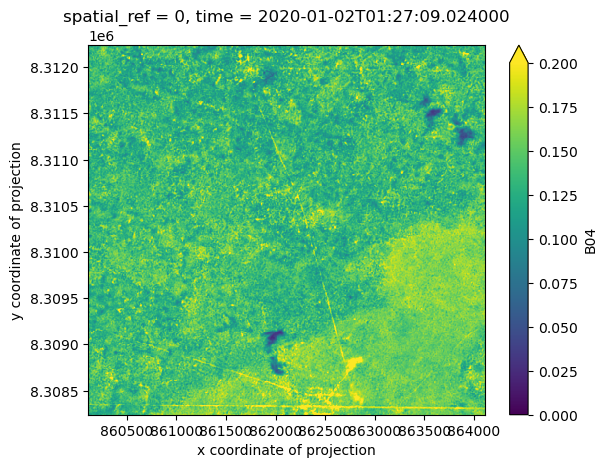

In [12]:
ds.B04.isel(time=0).plot(vmin=0., vmax=0.2)

In [13]:
ds = msds.stores.storage.open_data("AU-Dry_era5.zarr")
ds

<xarray.Dataset> Size: 35kB
Dimensions:    (time: 2160)
Coordinates:
  * time       (time) datetime64[ns] 17kB 2020-01-01 ... 2020-03-30T23:00:00
    latitude   float64 8B ...
    longitude  float64 8B ...
Data variables:
    d2m        (time) float32 9kB dask.array<chunksize=(2160,), meta=np.ndarray>
    t2m        (time) float32 9kB dask.array<chunksize=(2160,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

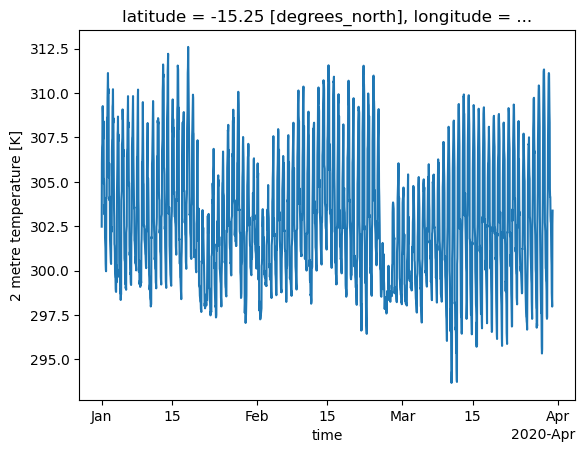

In [14]:
ds.t2m.plot()

In [15]:
ds = msds.stores.storage.open_data("AU-Dry_ccibiomass.zarr")
ds

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 1, y: 400, x: 400)
Coordinates:
  * time         (time) datetime64[ns] 8B 2020-07-01T23:59:59
  * y            (y) float64 3kB 8.312e+06 8.312e+06 ... 8.308e+06 8.308e+06
  * x            (x) float64 3kB 8.601e+05 8.601e+05 ... 8.641e+05 8.641e+05
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, y, x) float32 640kB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    agb_sd       (time, y, x) float32 640kB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    date_created:            2026-02-11T15:08:18.827024
    history:                 [{'cube_params': {'time_range': ['2020-01-01T00:...
    processing_level:        L4
    time_coverage_duration:  P365DT23H59M59S
    time_coverage_end:       2020-12-31T23:59:59
    time_coverage_start:     2020-01-01T00:00:00
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...

In [16]:
ds.agb.values

array([[[1.3596768 , 1.2052066 , 1.0500824 , ..., 0.09494666,
         0.10615102, 0.11702477],
        [1.1075878 , 0.9743503 , 0.84045887, ..., 0.1752329 ,
         0.19705275, 0.218542  ],
        [0.85615265, 0.7441479 , 0.6314892 , ..., 0.25584972,
         0.28828505, 0.32038978],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]], shape=(1, 400, 400), dtype=float32)

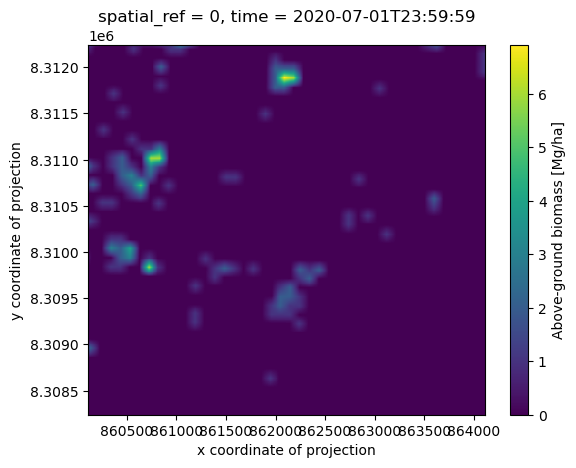

In [17]:
ds["agb"].plot()